In [ ]:
# 🔬 Prédiction de Maladies Basée sur des Symptômes

## 🎯 Objectif
Ce projet vise à prédire la présence potentielle de maladies cardiaques à partir des symptômes d’un patient en utilisant des algorithmes d'apprentissage automatique.

## 🛠 Méthodologie
- 📊 **Données** : 303 entrées patient avec 13 caractéristiques (âge, tension, cholestérol, etc.)
- 🤖 **Modèles utilisés** : Random Forest & Régression Logistique
- 🧪 **Évaluation** : Accuracy, Précision, Recall, F1-Score, Matrice de confusion
- 📈 **Interprétabilité** : Importance des caractéristiques visuellement analysée
- 🧠 **Usage** : Possibilité de tester des cas manuellement (ex: input utilisateur)

## ✅ Résultat
Un modèle fiable et prêt à être intégré dans une interface de diagnostic — base solide pour une future application clinique.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

print("✅ All packages are installed and ready.")


✅ All packages are installed and ready.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [27]:
import pandas as pd

df=pd.read_csv('heartV2.csv')


In [87]:
df.head()

,age,sex,TdT,P_art,chol,Glyc,restecg,freq_cardM,exng,oldpeak,slp,Nvp,thall,output,Date,city
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,2021-09-22,Cardiff
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,2022-11-27,Birmingham
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,2023-03-08,Édimbourg
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,2021-02-25,Londres
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,2022-12-09,Birmingham


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         303 non-null    int64  
 1   sex         303 non-null    int64  
 2   TdT         303 non-null    int64  
 3   P_art       303 non-null    int64  
 4   chol        303 non-null    int64  
 5   Glyc        303 non-null    int64  
 6   restecg     303 non-null    int64  
 7   freq_cardM  303 non-null    int64  
 8   exng        303 non-null    int64  
 9   oldpeak     303 non-null    float64
 10  slp         303 non-null    int64  
 11  Nvp         303 non-null    int64  
 12  thall       303 non-null    int64  
 13  output      303 non-null    int64  
 14  Date        303 non-null    object 
 15  city        303 non-null    object 
dtypes: float64(1), int64(13), object(2)
memory usage: 38.0+ KB


## Pré-traitement des données

### Normalisation 

In [14]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
x=df.iloc[:,:13]
y=df.iloc[:,13]
x=x.values
y=y.values

In [8]:
from sklearn.preprocessing import MinMaxScaler

x = df.iloc[:, :13].values
# Normalisation Min-Max
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

In [25]:
import joblib
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.3,\
                                                random_state=0)

In [16]:
print(X_train.shape)
print(X_test.shape)

(212, 13)
(91, 13)


In [17]:
print(X_train.mean())
print(X_test.mean())

45.51436865021771
45.0916314454776


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Initialize models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(max_iter=1000)

# Train both models
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [19]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Predict
rf_pred = rf_model.predict(X_test)
lr_pred = lr_model.predict(X_test)

# Evaluation function
def evaluate_model(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

# Evaluate
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("Logistic Regression", y_test, lr_pred)


--- Random Forest ---
Accuracy: 0.8461538461538461
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.75      0.82        44
           1       0.80      0.94      0.86        47

    accuracy                           0.85        91
   macro avg       0.86      0.84      0.84        91
weighted avg       0.86      0.85      0.84        91

--- Logistic Regression ---
Accuracy: 0.8131868131868132
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.73      0.79        44
           1       0.78      0.89      0.83        47

    accuracy                           0.81        91
   macro avg       0.82      0.81      0.81        91
weighted avg       0.82      0.81      0.81        91



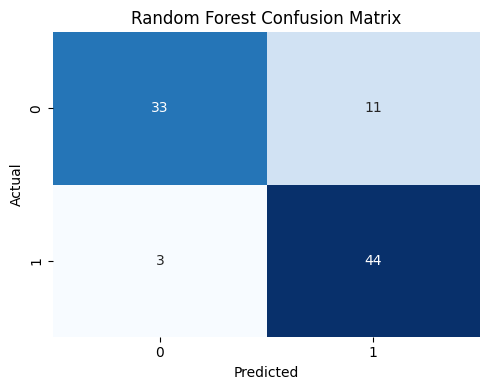

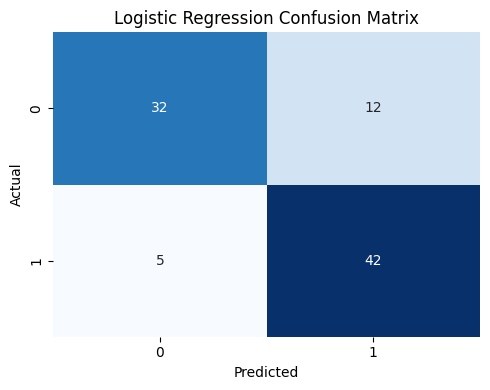

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Plot for both models
plot_confusion_matrix(y_test, rf_pred, "Random Forest Confusion Matrix")
plot_confusion_matrix(y_test, lr_pred, "Logistic Regression Confusion Matrix")


In [22]:
# Example input: [age, sex, TdT, P_art, chol, Glyc, restecg, freq_cardM, exng, oldpeak, slp, Nvp, thall]
sample = [[55, 1, 1, 140, 250, 1, 0, 160, 0, 1.2, 1, 0, 2]]

# Don't forget to scale it like the training data
sample_scaled = scaler.transform(sample)

# Predict using Random Forest
prediction = rf_model.predict(sample_scaled)

# Output result
print("Prediction:", prediction[0])
print("1 = Disease present, 0 = No disease")


Prediction: 1
1 = Disease present, 0 = No disease


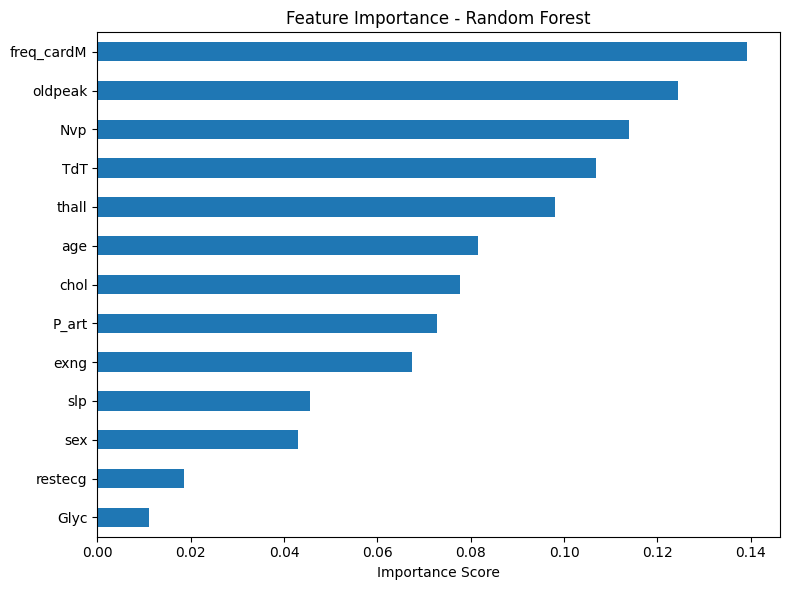

In [23]:
# Feature names (from dataset)
feature_names = df.columns[:13]

# Get importance from the trained Random Forest model
importances = rf_model.feature_importances_

# Visualize it
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8, 6))
(pd.Series(importances, index=feature_names)
   .sort_values()
   .plot(kind='barh', title="Feature Importance - Random Forest"))
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


### Random Forest

In [24]:
import joblib
joblib.dump(rf_model, "best_model.pkl")


['best_model.pkl']

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


rf = RandomForestClassifier(n_estimators=500)


In [15]:
rf.fit(X_train,y_train)


RandomForestClassifier(n_estimators=500)

In [16]:
y_pred_rf = rf.predict(X_test)


In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

print('Matrice de confusion:\n', confusion_matrix(y_test,y_pred_rf))
print('Accuracy :', accuracy_score(y_test,y_pred_rf))
print('Recall :', recall_score(y_test,y_pred_rf))
print('Precision :', precision_score(y_test,y_pred_rf))

Matrice de confusion:
 [[32 12]
 [ 5 42]]
Accuracy : 0.8131868131868132
Recall : 0.8936170212765957
Precision : 0.7777777777777778


In [1]:
def Saisie():
    while True: 
        a = float(input('Veuillez saisir l’âge : '))
        if 0 <= a <= 120:
            break
        else: 
            print("L’âge doit être compris entre 0 et 120 ! ")

    while True:
        b = float(input('Veuillez saisir le sexe (0=femme, 1=homme) : '))
        if b in [0, 1]:
            break
        else: 
            print("Le sexe doit être 0 ou 1 ! ")

    while True:
        c = float(input('Veuillez saisir le type de douleur thoracique (0 à 3) : '))
        if 0 <= c <= 3:
            break
        else: 
            print("Le type de douleur doit être entre 0 et 3 ! ")

    while True:
        d = float(input('Veuillez saisir la pression artérielle : '))
        if 50 <= d <= 250:
            break
        else: 
            print("Valeur incohérente ! ")

    while True:
        e = float(input('Veuillez saisir le cholestérol : '))
        if 100 <= e <= 600:
            break
        else: 
            print("Valeur incohérente ! ")

    while True:
        f = float(input('Veuillez saisir la glycémie (0 ou 1) : '))
        if f in [0, 1]:
            break
        else: 
            print("La glycémie doit être 0 ou 1 ! ")

    while True:
        g = float(input('Veuillez saisir le restecg (0 à 2) : '))
        if 0 <= g <= 2:
            break
        else: 
            print("restecg doit être entre 0 et 2 ! ")

    while True:
        h = float(input('Veuillez saisir la fréquence cardiaque max : '))
        if 50 <= h <= 250:
            break
        else: 
            print("Valeur incohérente ! ")

    while True:
        i = float(input('Angine induite par effort ? (0 = non, 1 = oui) : '))
        if i in [0, 1]:
            break
        else: 
            print("Valeur doit être 0 ou 1 ! ")

    while True:
        j = float(input('Veuillez saisir oldpeak : '))
        if 0 <= j <= 10:
            break
        else: 
            print("Oldpeak doit être entre 0 et 10 ! ")

    while True:
        k = float(input('Veuillez saisir slp (0 à 2) : '))
        if k in [0, 2]:
            break
        else: 
            print("slp doit être entre 0 et 2 ! ")

    while True:
        l = float(input('Veuillez saisir Nvp (0 à 3) : '))
        if l in [0,3]:
            break
        else: 
            print("Nvp doit être entre 0 et 3 ! ")

    while True:
        m = float(input('Veuillez saisir thall (1 = normal, 2 = fixation, 3 = réversible) : '))
        if m in [1, 2, 3]:
            break
        else: 
            print("Thall doit être 1, 2 ou 3 ! ")

    return a, b, c, d, e, f, g, h, i, j, k, l, m


In [2]:
import pandas as pd

def pred(rf, scaler):
    # Saisie des valeurs du patient via la fonction Saisie()
    a, b, c, d, e, f, g, h, i, j, k, l, m = Saisie()

    # Création du DataFrame avec les données saisies
    data = {
        'age': [a],
        'sex': [b],
        'TdT': [c],
        'P_art': [d],
        'chol': [e],
        'Glyc': [f],
        'restecg': [g],
        'freq_cardM': [h],
        'exng': [i],
        'oldpeak': [j],
        'slp': [k],
        'Nvp': [l],
        'thall': [m]
    }
    
    # Création d'un DataFrame
    x = pd.DataFrame(data)
    
    # Normalisation des données
    x_scaled = scaler.transform(x)
    
    # Prédiction avec le modèle
    pred = rf.predict(x_scaled)
    
    # Affichage du résultat
    if pred[0] == 0:
        print('Prédiction : Sain')
    else:
        print('Prédiction : Malade')


In [3]:
pred(rf,scaler)

NameError: name 'rf' is not defined